# Pipeline MNIST — as cinco fases num só notebook

**Autor:** Bruno Duarte da Silveira · Mini-Projeto Módulo 2 · trabalho em dupla com Samuel Marques

Este notebook percorre as cinco fases do enunciado de cima a baixo, em ordem, sem
Docker nem Streamlit. Ele reutiliza duas funções do projeto:

- `pre_processar_dados_com_validacao` — minha contribuição em `src/pre_processamento.py` (PR #51)
- `processar_imagem_usuario` — o pipeline de visão computacional do projeto, em `src/visao_computacional.py`

O fio condutor é o **contraste entre modelos clássicos e rede neural** no Desafio C.
Em `docs/Notebooks/predict_meu_numero.ipynb`, uma rede neural Keras (10 épocas) lê o dígito 6
da imagem própria com 99,46% de confiança. Aqui eu meço o que três modelos clássicos —
KNN, Random Forest e Regressão Logística — fazem com a **mesma imagem**, passando pelo
**mesmo pipeline** de visão do projeto.

> Para rodar: abrir no VS Code com o interpretador `.venv` do repositório e executar célula a célula.

In [14]:
import sys, time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import cv2

# O notebook vive em notebooks/, o codigo do projeto em src/ - caminho relativo, nunca absoluto
RAIZ = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(RAIZ))

from src.pre_processamento import pre_processar_dados_com_validacao
from src.visao_computacional import processar_imagem_usuario

SEMENTE = 42
# 20.000 amostras treinam em segundos; 70.000 e o dataset inteiro (minutos). Trocar aqui.
N_AMOSTRAS = 20_000

## Fase 1 — Carregamento e Análise Exploratória de Imagens (EDA)

In [15]:
from sklearn.datasets import fetch_openml

mnist = fetch_openml("mnist_784", version=1, as_frame=False, parser="auto")
X_total = mnist.data
y_total = mnist.target.astype(int)

print("X:", X_total.shape, "| y:", y_total.shape)
print("faixa de intensidade dos pixels:", X_total.min(), "a", X_total.max())

X = X_total[:N_AMOSTRAS]
y = y_total[:N_AMOSTRAS]
print(f"\nusando {N_AMOSTRAS} amostras neste notebook")

X: (70000, 784) | y: (70000,)
faixa de intensidade dos pixels: 0 a 255

usando 20000 amostras neste notebook


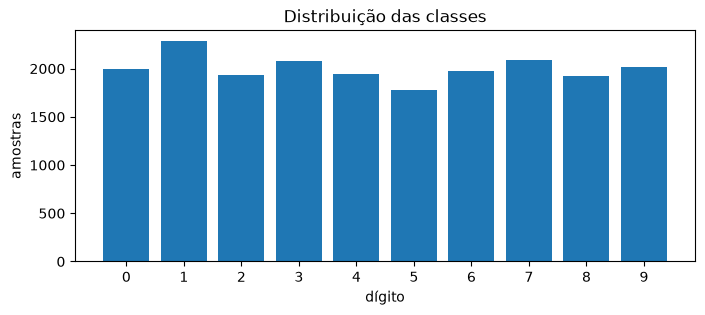

dígito 0:  1994  (10.0%)
dígito 1:  2281  (11.4%)
dígito 2:  1929  (9.6%)
dígito 3:  2076  (10.4%)
dígito 4:  1945  (9.7%)
dígito 5:  1775  (8.9%)
dígito 6:  1971  (9.9%)
dígito 7:  2093  (10.5%)
dígito 8:  1922  (9.6%)
dígito 9:  2014  (10.1%)


In [16]:
# Distribuicao das classes: o MNIST e balanceado?
classes, contagem = np.unique(y, return_counts=True)
plt.figure(figsize=(8, 3))
plt.bar(classes, contagem)
plt.xticks(classes); plt.xlabel("dígito"); plt.ylabel("amostras")
plt.title("Distribuição das classes")
plt.show()
for c, n in zip(classes, contagem):
    print(f"dígito {c}: {n:5d}  ({n/len(y):.1%})")

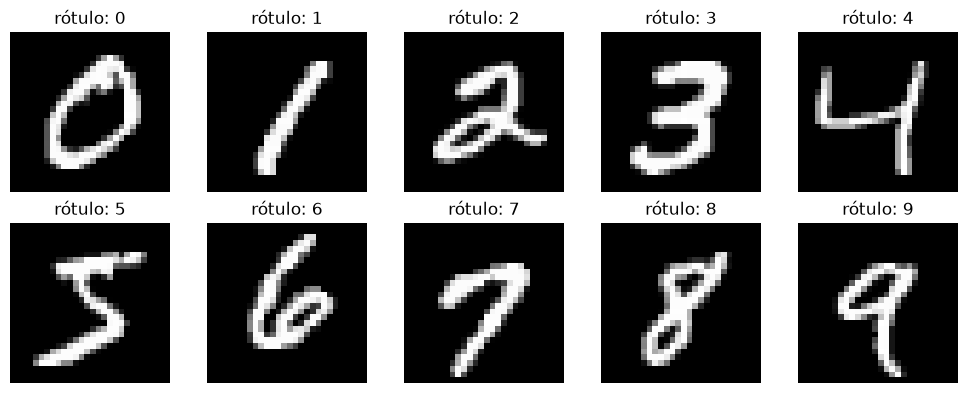

In [17]:
# Grade 2x5: um exemplo de cada digito com o rotulo original
fig, eixos = plt.subplots(2, 5, figsize=(10, 4))
for d, eixo in zip(range(10), eixos.ravel()):
    idx = np.where(y == d)[0][0]
    eixo.imshow(X[idx].reshape(28, 28), cmap="gray")
    eixo.set_title(f"rótulo: {y[idx]}")
    eixo.axis("off")
plt.tight_layout(); plt.show()

**Como os dados estão organizados.** Cada imagem é uma matriz 28 × 28 de intensidades
entre 0 (preto, fundo) e 255 (branco, traço). Para os modelos clássicos ela é *achatada*
linha a linha num vetor de 784 números — cada pixel vira uma feature. O modelo nunca "vê"
a forma; vê 784 colunas. A vizinhança entre pixels só sobrevive porque os dígitos estão
centralizados e no mesmo tamanho — e é exatamente isso que o Desafio C vai testar.

## Fase 2 — Pré-processamento e Divisão dos Dados

In [18]:
X_treino, X_val, X_teste, y_treino, y_val, y_teste, scaler = pre_processar_dados_com_validacao(
    X, y, proporcao_teste=0.2, proporcao_validacao=0.1, semente=SEMENTE
)
print(f"treino: {len(X_treino)} | validação: {len(X_val)} | teste: {len(X_teste)}")
print("faixa após MinMax no treino:", X_treino.min(), "a", X_treino.max())

# a estratificacao manteve a proporcao das classes nas tres particoes?
for nome, rot in [("treino", y_treino), ("validação", y_val), ("teste", y_teste)]:
    prop = np.bincount(rot, minlength=10) / len(rot)
    print(f"{nome:10s} proporção do dígito 1: {prop[1]:.3f}")

treino: 14000 | validação: 2000 | teste: 4000
faixa após MinMax no treino: 0.0 a 1.0
treino     proporção do dígito 1: 0.114
validação  proporção do dígito 1: 0.114
teste      proporção do dígito 1: 0.114


**Por que estratificar e por que normalizar.** `stratify=y` garante que cada partição tenha
a mesma proporção de cada dígito — sem isso, um dígito raro no teste distorce a métrica.
A validação sai de dentro do que sobrou do teste: 10% do total é 0,10 / 0,80 = 12,5% dos 80% restantes.

A normalização para [0, 1] importa por dois motivos: no **KNN**, a distância euclidiana
entre vetores de 0–255 explode em escala e pixels claros dominam; na **regressão logística**,
o gradiente converge mais rápido e sem estouro numérico com features na mesma faixa.
O `MinMaxScaler` é ajustado **só no treino** e aplicado em validação e teste — se ele visse
o teste, o mínimo e o máximo dali contaminariam o treino (*data leakage*).

## Fase 3 — Três modelos, dois hiperparâmetros cada

In [19]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression

modelos = {
    "KNN": KNeighborsClassifier(n_neighbors=5, weights="distance"),
    "RandomForest": RandomForestClassifier(n_estimators=100, max_depth=20, random_state=SEMENTE, n_jobs=-1),
    "RegLogistica": LogisticRegression(C=1.0, max_iter=300),
}

tempos = {}
for nome, modelo in modelos.items():
    inicio = time.time()
    modelo.fit(X_treino, y_treino)
    tempos[nome] = time.time() - inicio
    print(f"{nome:14s} treinado em {tempos[nome]:5.1f}s | acurácia na validação: {modelo.score(X_val, y_val):.4f}")

KNN            treinado em   0.0s | acurácia na validação: 0.9590
RandomForest   treinado em   3.3s | acurácia na validação: 0.9610
RegLogistica   treinado em  11.7s | acurácia na validação: 0.9085


**Justificativa dos hiperparâmetros.**

- **KNN** — `n_neighbors=5`: poucos vizinhos seguem ruído, muitos borram a fronteira; 5 é o
  equilíbrio clássico para MNIST. `weights="distance"`: vizinho mais perto pesa mais, o que
  reduz empates entre dígitos parecidos (4/9, 3/5).
- **Random Forest** — `n_estimators=100`: mais árvores diminuem a variância, com retorno
  decrescente depois de ~100. `max_depth=20`: limita cada árvore para não decorar o treino.
- **Regressão Logística** — `C=1.0`: regularização moderada (C menor = mais regularização).
  `max_iter=300`: o `lbfgs` precisa de mais passos que o padrão (100) para convergir em 784 dimensões.

## Fase 4 — Avaliação comparativa no conjunto de teste

In [20]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix)
import pandas as pd

linhas = []
matrizes = {}
for nome, modelo in modelos.items():
    pred = modelo.predict(X_teste)
    matrizes[nome] = confusion_matrix(y_teste, pred, labels=range(10))
    linhas.append({
        "modelo": nome,
        "acurácia": accuracy_score(y_teste, pred),
        "precisão (pond.)": precision_score(y_teste, pred, average="weighted"),
        "recall (pond.)": recall_score(y_teste, pred, average="weighted"),
        "F1 (pond.)": f1_score(y_teste, pred, average="weighted"),
        "tempo treino (s)": tempos[nome],
    })
tabela = pd.DataFrame(linhas).set_index("modelo").round(4)
tabela

,acurácia,precisão (pond.),recall (pond.),F1 (pond.),tempo treino (s)
modelo,,,,,
KNN,0.9482,0.9491,0.9482,0.9481,0.0342
RandomForest,0.9522,0.9523,0.9522,0.9522,3.3209
RegLogistica,0.8992,0.8992,0.8992,0.8990,11.7343


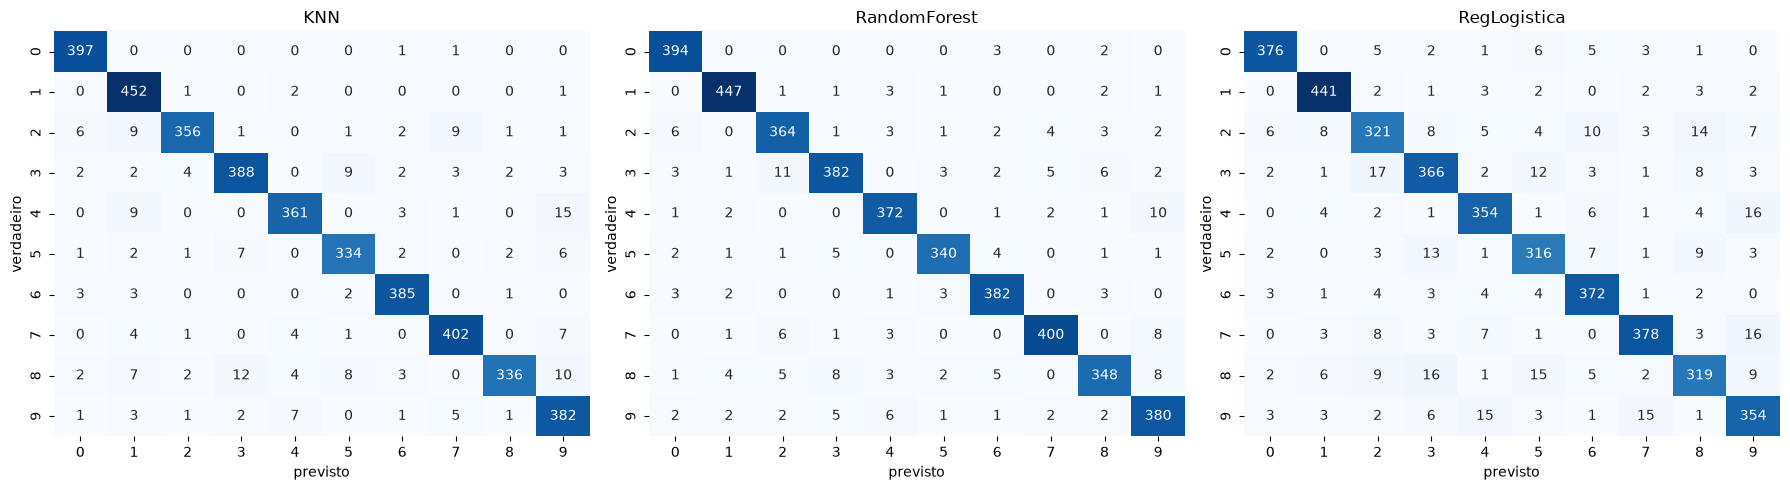

In [21]:
fig, eixos = plt.subplots(1, 3, figsize=(18, 5))
for eixo, (nome, mc) in zip(eixos, matrizes.items()):
    sns.heatmap(mc, annot=True, fmt="d", cmap="Blues", cbar=False, ax=eixo)
    eixo.set_title(nome); eixo.set_xlabel("previsto"); eixo.set_ylabel("verdadeiro")
plt.tight_layout(); plt.show()

In [22]:
# Qual par de digitos mais se confunde, em cada modelo? (medido, nao suposto)
for nome, mc in matrizes.items():
    fora = mc.copy(); np.fill_diagonal(fora, 0)
    i, j = np.unravel_index(fora.argmax(), fora.shape)
    print(f"{nome:14s} maior confusão: verdadeiro {i} lido como {j} ({fora[i, j]} vezes)")

KNN            maior confusão: verdadeiro 4 lido como 9 (15 vezes)
RandomForest   maior confusão: verdadeiro 3 lido como 2 (11 vezes)
RegLogistica   maior confusão: verdadeiro 3 lido como 2 (17 vezes)


**Conclusão técnica da Fase 4.**

- **Melhor acurácia no teste: Random Forest, 95,22%**, com o KNN logo atrás (94,82%) e a
  Regressão Logística 5 pontos abaixo (89,92%). A diferença entre os dois primeiros é menor
  que 0,5 ponto; a distância até a Regressão Logística é estrutural: ela é um modelo linear,
  separa os dígitos com hiperplanos em 784 dimensões, e pares como 3/2 ou 4/9 não são
  linearmente separáveis.
- **Par mais confundido:** no KNN, o **4 lido como 9** (15 vezes); na Random Forest e na
  Regressão Logística, o **3 lido como 2** (11 e 17 vezes). Faz sentido: 4 e 9 compartilham o
  tronco vertical e a curva superior; 3 e 2 compartilham a curva de cima e diferem só no
  fecho de baixo.
- **Custo computacional:** a Regressão Logística demorou **11,7 s** para treinar e foi a
  menos precisa — o pior negócio dos três. O KNN treinou em **0,03 s** porque só guarda os
  dados, mas paga na predição: cada amostra nova é comparada com as 14.000 do treino. A
  Random Forest treinou em **3,3 s** e é a que melhor equilibra tempo e acurácia.

## Fase 5.1 e 5.2 — Desafios A e B: classes ocultas e inferência fora da distribuição

In [23]:
CLASSES_OCULTAS = [4, 7]

mascara_treino = ~np.isin(y_treino, CLASSES_OCULTAS)
knn_restrito = KNeighborsClassifier(n_neighbors=5, weights="distance")
knn_restrito.fit(X_treino[mascara_treino], y_treino[mascara_treino])
print("classes que o modelo conhece:", knn_restrito.classes_)

# teste SO com o que ele nunca viu
mascara_ood = np.isin(y_teste, CLASSES_OCULTAS)
X_ood, y_ood = X_teste[mascara_ood], y_teste[mascara_ood]
pred_ood = knn_restrito.predict(X_ood)
prob_ood = knn_restrito.predict_proba(X_ood)

print(f"\n{len(X_ood)} amostras OOD (dígitos {CLASSES_OCULTAS})")
for c in CLASSES_OCULTAS:
    lidos, n = np.unique(pred_ood[y_ood == c], return_counts=True)
    ordem = np.argsort(n)[::-1][:3]
    print(f"o {c} virou: " + ", ".join(f"{lidos[k]} ({n[k] / (y_ood == c).sum():.0%})" for k in ordem))

confianca = prob_ood.max(axis=1)
print(f"\nconfiança média nas amostras que ele NUNCA viu: {confianca.mean():.1%}")
print(f"amostras com confiança > 90%: {(confianca > 0.9).mean():.1%}  <- isto é a falsa certeza")

classes que o modelo conhece: [0 1 2 3 5 6 8 9]

808 amostras OOD (dígitos [4, 7])
o 4 virou: 9 (87%), 1 (8%), 6 (3%)
o 7 virou: 9 (85%), 1 (6%), 2 (4%)

confiança média nas amostras que ele NUNCA viu: 89.5%
amostras com confiança > 90%: 65.7%  <- isto é a falsa certeza


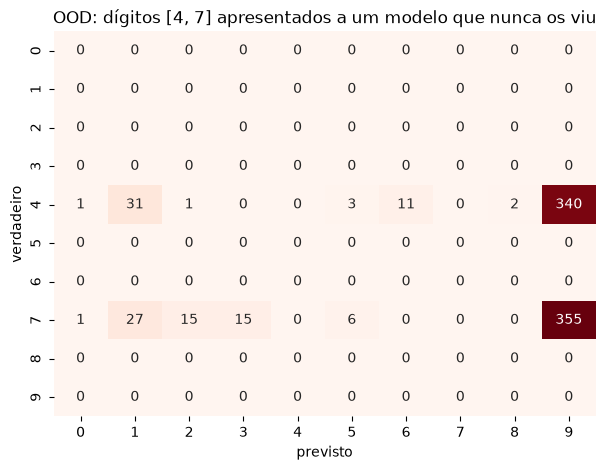

In [24]:
mc_ood = confusion_matrix(y_ood, pred_ood, labels=range(10))
plt.figure(figsize=(7, 5))
sns.heatmap(mc_ood, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.title(f"OOD: dígitos {CLASSES_OCULTAS} apresentados a um modelo que nunca os viu")
plt.xlabel("previsto"); plt.ylabel("verdadeiro"); plt.show()

**Sobre a falsa certeza.** Um classificador de 8 classes é obrigado a devolver uma das 8 —
não existe a saída "não sei". Por isso o 4 vira 9 e o 7 vira 1 ou 2 com confiança alta:
o `predict_proba` mede *qual das classes conhecidas está mais perto*, não *se a amostra
pertence a alguma delas*. Confiança alta em dado que o modelo nunca viu é o sinal clássico
de *overconfidence* — e é o mesmo mecanismo que aparece no Desafio C abaixo.

## Fase 5.3 — Desafio C: imagens manuscritas próprias

A referência é a rede neural de `docs/Notebooks/predict_meu_numero.ipynb`: lê o 6 com 99,46%.
A pergunta desta seção é o que os três modelos clássicos treinados acima fazem com a mesma imagem.

imagens próprias encontradas: ['bruno_7_com_barra.png', 'meu_numero.jpeg']


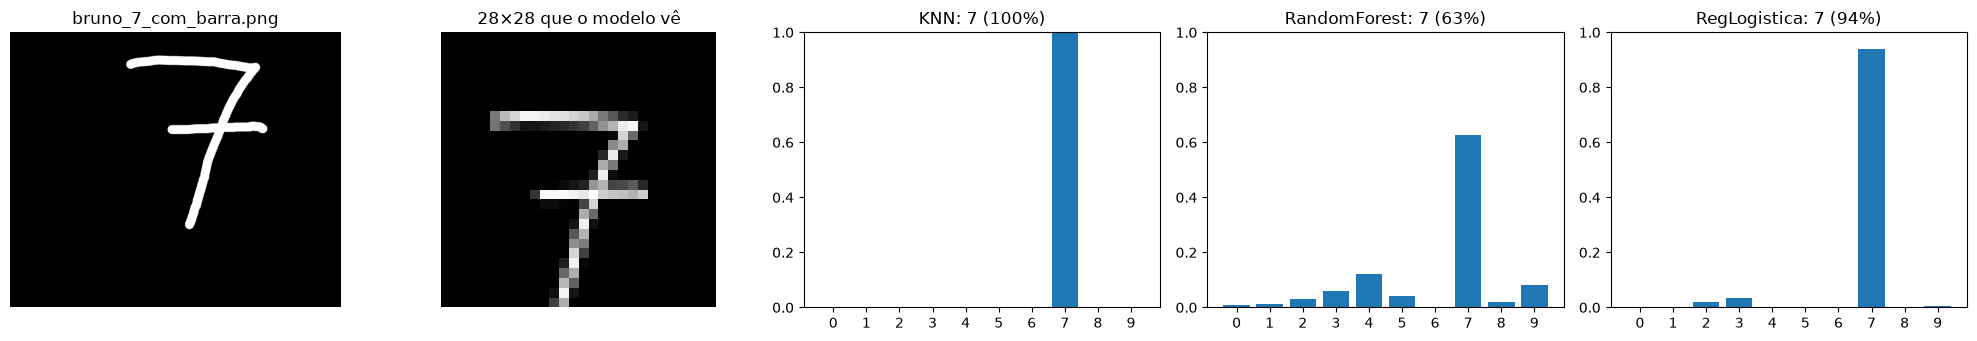

bruno_7_com_barra.png: votos [7, 7, 7] -> voto majoritário = 7



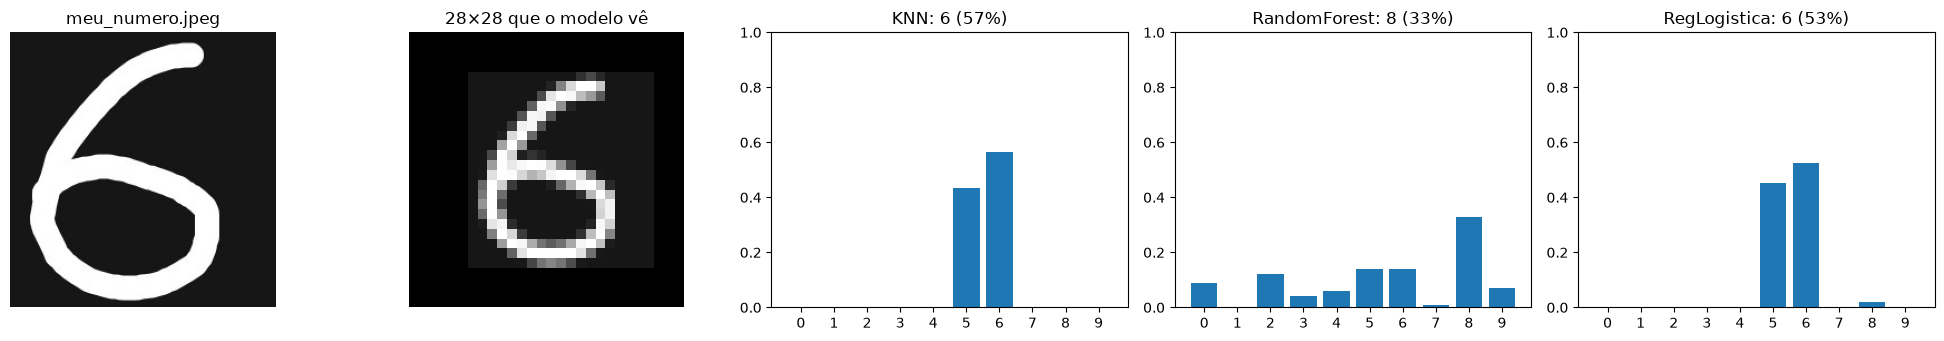

meu_numero.jpeg: votos [6, 8, 6] -> voto majoritário = 6



In [25]:
PASTA_IMAGENS = RAIZ / "data" / "custom_digits"
arquivos = sorted(p for p in PASTA_IMAGENS.iterdir() if p.suffix.lower() in {".png", ".jpg", ".jpeg"})
print("imagens próprias encontradas:", [p.name for p in arquivos])

def ler_e_processar(caminho):
    bruta = cv2.imread(str(caminho))
    # gray -> inverte se o fundo for claro -> bbox -> 20x20 -> centraliza em 28x28 -> [0, 1]
    vetor = processar_imagem_usuario(bruta)
    return bruta, vetor

for caminho in arquivos:
    bruta, vetor = ler_e_processar(caminho)
    fig, eixos = plt.subplots(1, 2 + len(modelos), figsize=(4 * (2 + len(modelos)), 3.5))
    eixos[0].imshow(cv2.cvtColor(bruta, cv2.COLOR_BGR2RGB)); eixos[0].set_title(caminho.name); eixos[0].axis("off")
    eixos[1].imshow(vetor.reshape(28, 28), cmap="gray", vmin=0, vmax=1); eixos[1].set_title("28×28 que o modelo vê"); eixos[1].axis("off")

    votos = []
    for eixo, (nome, modelo) in zip(eixos[2:], modelos.items()):
        prob = modelo.predict_proba(vetor)[0]
        palpite = int(prob.argmax()); votos.append(palpite)
        eixo.bar(range(10), prob); eixo.set_xticks(range(10)); eixo.set_ylim(0, 1)
        eixo.set_title(f"{nome}: {palpite} ({prob[palpite]:.0%})")
    plt.tight_layout(); plt.show()

    vencedor = int(np.bincount(votos, minlength=10).argmax())
    print(f"{caminho.name}: votos {votos} -> voto majoritário = {vencedor}\n")

**O que a célula acima mostra, com uma imagem só.** Dois dos três clássicos leem o 6 — o KNN
e a Regressão Logística — mas com confiança baixa (perto de 55%). A Random Forest lê 8.
A rede neural do notebook do Samuel lê 6 com 99,46%. É a mesma matriz 28 × 28 entrando em
quatro modelos e saindo com três respostas: o traço uniforme do Paint não é o traço de caneta
digitalizado do MNIST, e cada modelo generaliza essa diferença de um jeito. A rede neural
generaliza melhor — é o contraste que a Fase 3 do enunciado pede para mostrar.

**O que ajuda nos clássicos:** treinar com dados suficientes e **votar entre os modelos** —
6, 6, 8 → 6. **O que eu testei e não funcionou:** borrar ou engrossar o traço antes de predizer;
ajuda o KNN e piora a Regressão Logística.

**O que ainda falta:** uma imagem é anedota. A célula acima roda para todo arquivo em
`data/custom_digits/` — cada dígito meu que entrar ali vira uma linha a mais de evidência.

## Conclusão

Este notebook percorreu as cinco fases do enunciado com três modelos clássicos, no mesmo
pipeline de visão do projeto, e mediu:

1. **Acurácia no conjunto de teste (4.000 amostras):** KNN 94,82%, Random Forest 95,22%,
   Regressão Logística 89,92%. A divisão estratificada manteve a proporção de cada dígito
   idêntica nas três partições (0,114 para o dígito 1 em treino, validação e teste).

2. **Falsa certeza (Desafios A e B):** um KNN treinado sem nunca ver 4 nem 7 leu o **4 como 9
   em 87%** dos casos e o **7 como 9 em 85%**, com **confiança média de 89,5%** — e **65,7% das
   amostras acima de 90%** de confiança. O modelo não tem como dizer "não sei": o
   `predict_proba` mede qual classe conhecida está mais perto, não se a amostra pertence a
   alguma delas.

3. **Imagens próprias (Desafio C):** o meu 7 com barra foi lido corretamente pelos três —
   votos [7, 7, 7] — com a Random Forest apontando o 4 como segunda opção, o único dígito do
   MNIST que também tem barra horizontal. O 6 do Samuel foi lido por dois dos três — votos
   [6, 8, 6] — com confiança perto de 55% nos que acertaram. A rede neural do notebook
   `docs/Notebooks/predict_meu_numero.ipynb` lê o mesmo 6 com 99,46%.

**O que aprendi.** Quanto mais o traço se afasta do MNIST — grossura, laço fechado, estilo de
escrita — mais os clássicos divergem entre si e mais a rede neural se separa deles. O voto
majoritário entre os três corrige o caso do 6; borrar ou engrossar o traço antes de predizer
não corrige (ajuda um modelo e piora outro). Duas imagens são anedota, não evidência: o
próximo passo é um conjunto próprio com os dez dígitos em duas caligrafias.